In [6]:
import os
import sys
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from torch.utils.data import DataLoader
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)
from dataloader import Dataset

transforms = v2.Compose([
    v2.Resize((256, 256)),
    v2.RandomCrop(224),
    v2.RandomHorizontalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = Dataset(
    patches_path="../data/CNRPark-EXT/PATCHES",
    labels_file="../data/CNRPark-EXT/LABELS/train.txt",
    transforms=transforms
)

def collate_fn(batch):
    images = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    return images, labels


Feature batch shape: 5
Labels batch shape: 5
Label: 1
torch.Size([3, 224, 224])


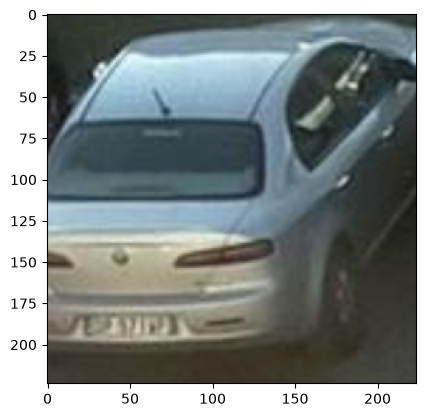

Label: 0
torch.Size([3, 224, 224])


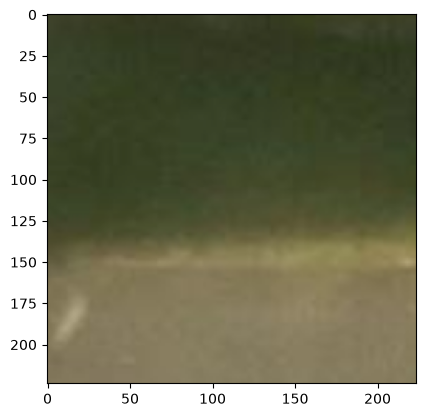

Label: 0
torch.Size([3, 224, 224])


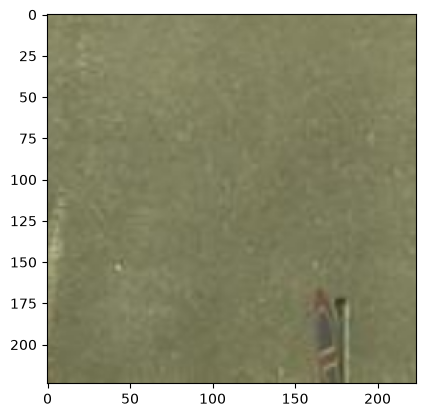

Label: 0
torch.Size([3, 224, 224])


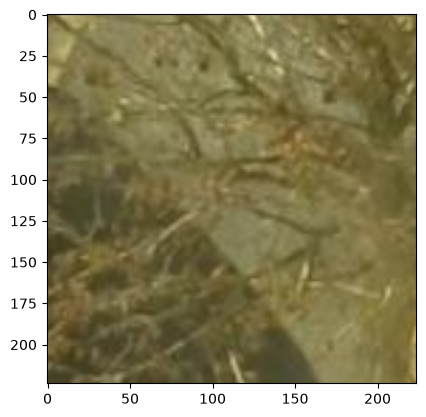

Label: 1
torch.Size([3, 224, 224])


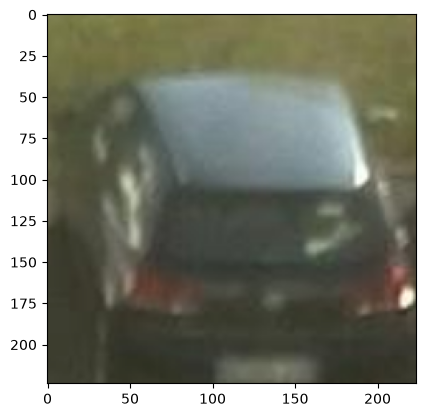

In [8]:
# Display image and label
batch_size = 5

train_dataloader = DataLoader(dataset, batch_size=5, shuffle=True, num_workers=0, drop_last=False, collate_fn=collate_fn)

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {len(train_features)}") 
print(f"Labels batch shape: {len(train_labels)}")

# Display the images and labels from the batch
for i in range(len(train_features)):
    
    img = train_features[i]
    label = train_labels[i]
    print(f"Label: {label}")
    print(img.shape)
    
    img_plot = img.permute(1, 2, 0) # fix colors ate the end (for visualization only)
    img_plot = img_plot / 2 + 0.5   # changes from [-1, 1], back to [0, 1]
    plt.imshow(img_plot)
    plt.show()